# Final Project Report - Introduction to Data Analytics
## Prediction/Analysis of World Happiness Scores using Socioeconomic Indicators
### Bruno Sagayam | AIGC-5000 | Humber College | Winter 2025

## 1. Problem Statement
Prediction/Analysis of World Happiness Scores using Socioeconomic and Wellbeing Indicators across 156 countries in 2019.

## 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 3. Load Dataset

In [3]:
df = pd.read_csv('archive/2019.csv')
df.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


## 4. Dataset Description

In [5]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Shape: (156, 9)

Columns: ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

Data Types:
 Overall rank                      int64
Country or region                object
Score                           float64
GDP per capita                  float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
dtype: object

Missing Values:
 Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64

Basic Statistics:


,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


## 5. Dataset Analysis and Observations
### 5.1 Univariate Analysis - Distribution of Happiness Score

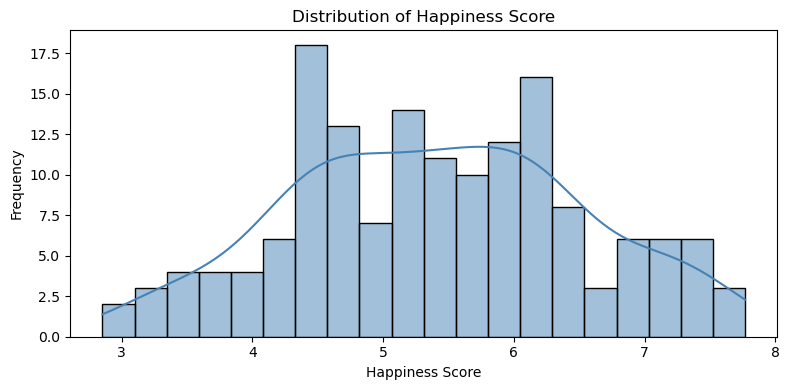

In [6]:
plt.figure(figsize=(8,4))
sns.histplot(df['Score'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of Happiness Score')
plt.xlabel('Happiness Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### 5.2 Bivariate Analysis - Features vs Happiness Score

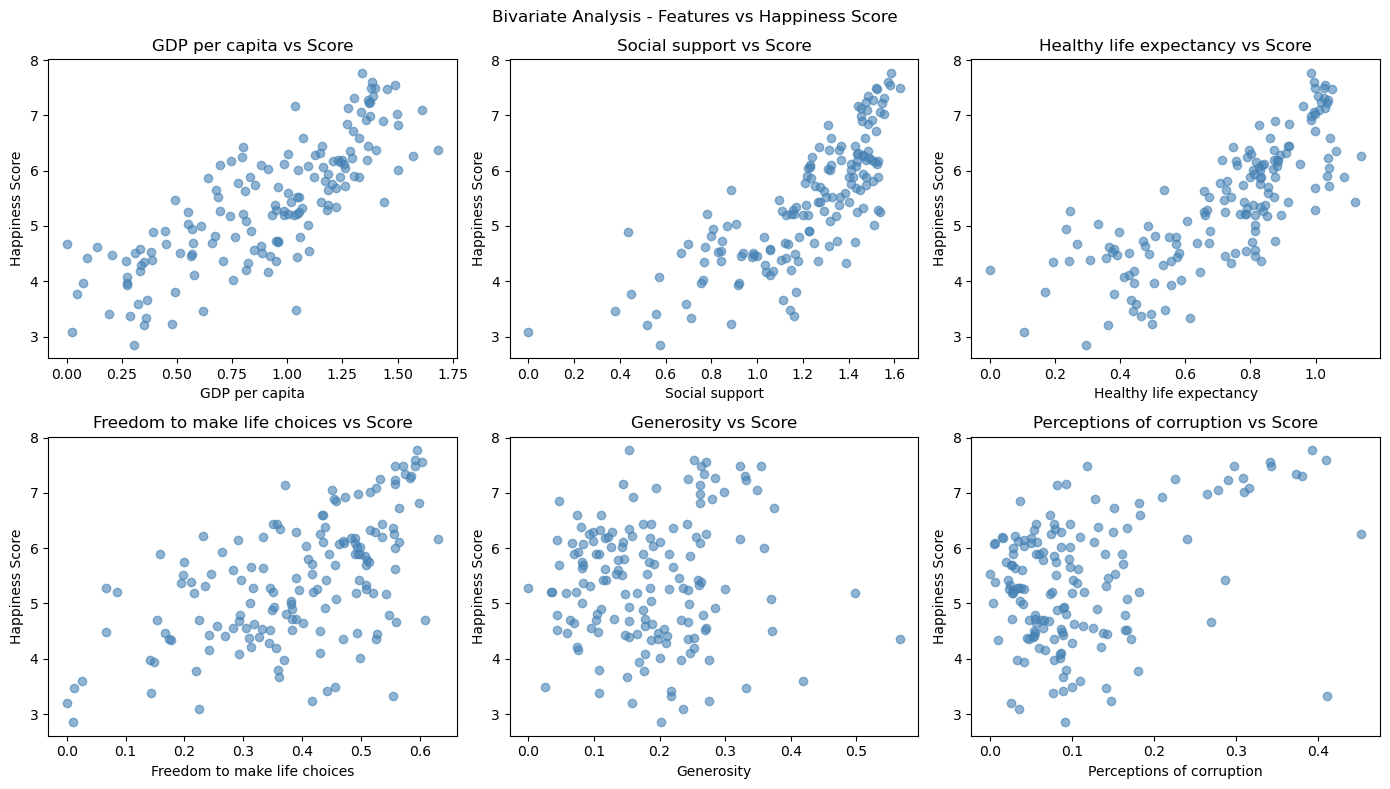

In [7]:
features = ['GDP per capita', 'Social support', 'Healthy life expectancy',
            'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].scatter(df[feature], df['Score'], color='steelblue', alpha=0.6)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Happiness Score')
    axes[i].set_title(f'{feature} vs Score')

plt.suptitle('Bivariate Analysis - Features vs Happiness Score')
plt.tight_layout()
plt.show()


### 5.3 Multivariate Analysis - Correlation Heatmap

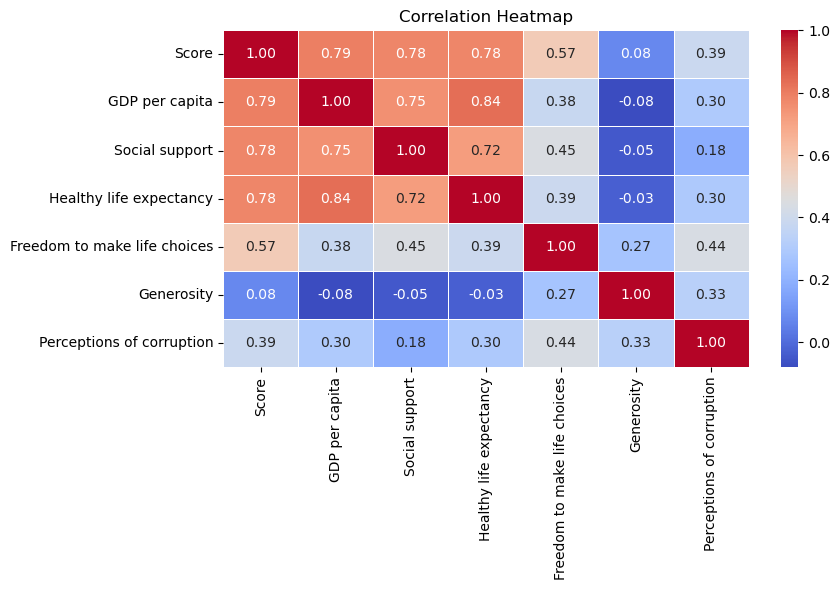

In [8]:
plt.figure(figsize=(9,6))
corr = df[['Score', 'GDP per capita', 'Social support', 'Healthy life expectancy',
           'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 6. Proposed Analytical/Prediction Model
### Multiple Linear Regression was selected because the target variable (Happiness Score) is continuous and multiple numeric features show linear relationships with the target, as confirmed by the bivariate and correlation analysis above.

In [9]:
features = ['GDP per capita', 'Social support', 'Healthy life expectancy',
            'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

X = df[features]
y = df['Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Model coefficients:", dict(zip(features, model.coef_.round(3))))

Training samples: 124
Testing samples: 32
Model coefficients: {'GDP per capita': np.float64(0.751), 'Social support': np.float64(1.232), 'Healthy life expectancy': np.float64(0.931), 'Freedom to make life choices': np.float64(1.49), 'Generosity': np.float64(0.27), 'Perceptions of corruption': np.float64(1.112)}


## 7. Results and Discussion

In [10]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics:")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R-Squared: {r2:.4f}")

Model Evaluation Metrics:
MAE:  0.4955
MSE:  0.4145
RMSE: 0.6438
R-Squared: 0.6018



### 7.1 Actual vs Predicted Happiness Score

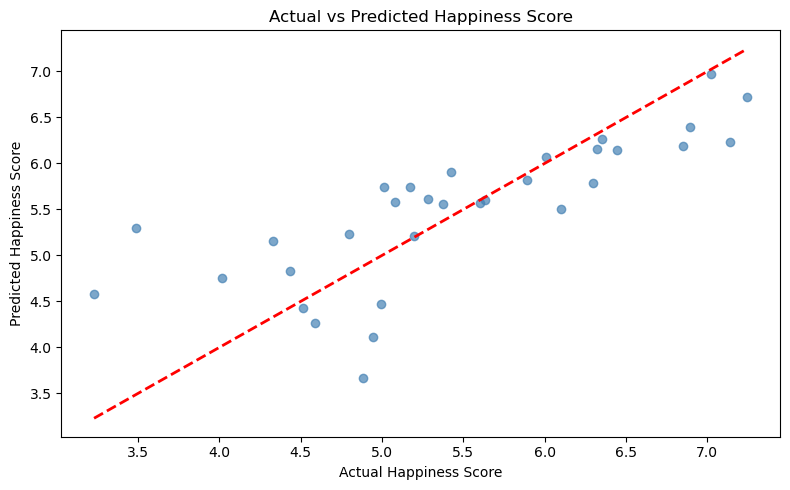

In [11]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, color='steelblue', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Happiness Score')
plt.ylabel('Predicted Happiness Score')
plt.title('Actual vs Predicted Happiness Score')
plt.tight_layout()
plt.show()

## 8. Conclusion

In [12]:
print("Conclusion:")
print("The Multiple Linear Regression model achieved an R-Squared of 0.60,")
print("meaning it explains 60% of the variance in World Happiness Scores.")
print("")
print("Key findings:")
print("- GDP per capita, Social support, and Healthy life expectancy")
print("  are the strongest predictors of happiness (correlation > 0.78)")
print("- Generosity showed the weakest relationship with happiness (0.08)")
print("- The model predicts happiness scores with an average error (MAE) of 0.50")
print("- Future improvements could include adding regional/geographic features")

Conclusion:
The Multiple Linear Regression model achieved an R-Squared of 0.60,
meaning it explains 60% of the variance in World Happiness Scores.

Key findings:
- GDP per capita, Social support, and Healthy life expectancy
  are the strongest predictors of happiness (correlation > 0.78)
- Generosity showed the weakest relationship with happiness (0.08)
- The model predicts happiness scores with an average error (MAE) of 0.50
- Future improvements could include adding regional/geographic features
